In [29]:
import os
import time
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

IMAGE_PATH = "/content/img.jpg"
OUTPUT_DIR = "/content/labwork9_results"

BLOCK_SIZES = [(4, 4), (8, 8), (16, 16), (32, 32), (64, 64)]

os.makedirs(OUTPUT_DIR, exist_ok=True)

image_bgr = cv2.imread(IMAGE_PATH)

if image_bgr is None:
    raise FileNotFoundError(f"Cannot load image: {IMAGE_PATH}")

image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

gray_image = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

height, width = gray_image.shape

print("Image loaded successfully")
print("RGB image shape:", image_rgb.shape)
print("Grayscale image shape:", gray_image.shape)
print("Image size:", width, "x", height)
print("Number of pixels:", height * width)
print("Output directory:", OUTPUT_DIR)

Image loaded successfully
RGB image shape: (1920, 1080, 3)
Grayscale image shape: (1920, 1080)
Image size: 1080 x 1920
Number of pixels: 2073600
Output directory: /content/labwork9_results


In [30]:
def serial_histogram(gray):
    hist = np.zeros(256, dtype=np.int64)

    height, width = gray.shape

    for y in range(height):
        for x in range(width):
            intensity = int(gray[y, x])
            hist[intensity] += 1

    return hist

start = time.perf_counter()

reference_histogram = serial_histogram(gray_image)

reference_histogram_time = time.perf_counter() - start

print("Reference histogram calculated.")
print("Histogram bins:", len(reference_histogram))
print("Total histogram count:", reference_histogram.sum())
print("Expected pixel count:", gray_image.size)
print("Correct:", reference_histogram.sum() == gray_image.size)
print(f"Reference histogram time: {reference_histogram_time:.6f} s")

Reference histogram calculated.
Histogram bins: 256
Total histogram count: 2073600
Expected pixel count: 2073600
Correct: True
Reference histogram time: 0.861508 s


In [31]:
def histogram_local_reduce(gray, block_size=(16, 16)):
    height, width = gray.shape
    block_h, block_w = block_size

    local_histograms = []

    for y0 in range(0, height, block_h):
        y1 = min(y0 + block_h, height)

        for x0 in range(0, width, block_w):
            x1 = min(x0 + block_w, width)

            block = gray[y0:y1, x0:x1]

            local_hist = np.zeros(256, dtype=np.int64)

            for y in range(block.shape[0]):
                for x in range(block.shape[1]):
                    intensity = int(block[y, x])
                    local_hist[intensity] += 1

            local_histograms.append(local_hist)

    global_histogram = np.zeros(256, dtype=np.int64)

    for local_hist in local_histograms:
        global_histogram += local_hist

    return global_histogram

In [32]:
MAIN_BLOCK_SIZE = (16, 16)

start = time.perf_counter()

histogram = histogram_local_reduce(gray_image, block_size=MAIN_BLOCK_SIZE)

histogram_time = time.perf_counter() - start

print("Labwork 9a - Histogram")
print("----------------------")
print("Block size:", MAIN_BLOCK_SIZE)
print("Histogram bins:", len(histogram))
print("Total histogram count:", histogram.sum())
print("Expected pixel count:", gray_image.size)
print("Correct:", np.array_equal(histogram, reference_histogram))
print(f"Execution time: {histogram_time:.6f} s")

Labwork 9a - Histogram
----------------------
Block size: (16, 16)
Histogram bins: 256
Total histogram count: 2073600
Expected pixel count: 2073600
Correct: True
Execution time: 0.898342 s


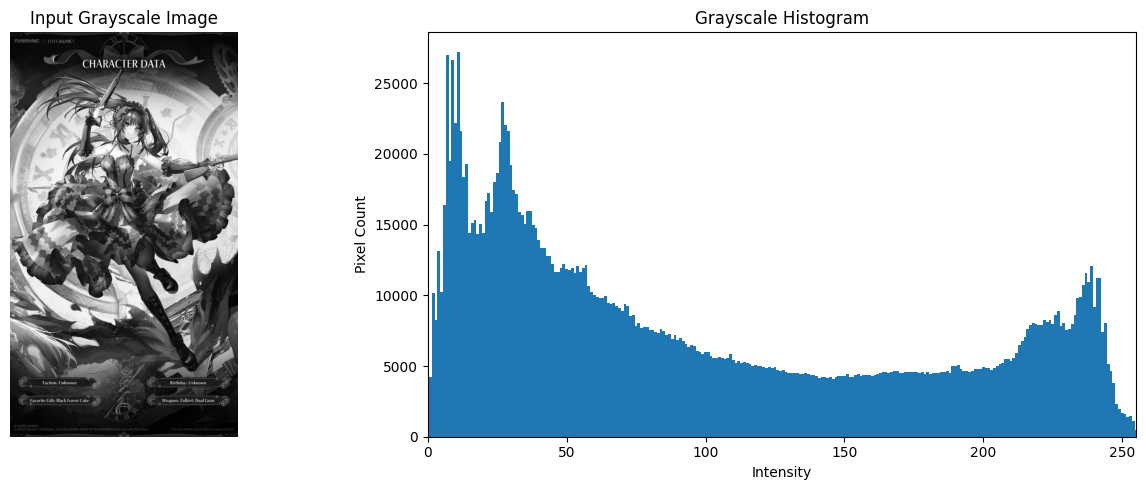

Saved: /content/labwork9_results/histogram.png


In [33]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.imshow(gray_image, cmap="gray")
plt.title("Input Grayscale Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.bar(np.arange(256), histogram, width=1.0)
plt.title("Grayscale Histogram")
plt.xlabel("Intensity")
plt.ylabel("Pixel Count")
plt.xlim(0, 255)

plt.tight_layout()

histogram_figure_path = os.path.join(OUTPUT_DIR, "histogram.png")

plt.savefig(histogram_figure_path, dpi=150, bbox_inches="tight")

plt.show()

print("Saved:", histogram_figure_path)

In [34]:
def calculate_probability(histogram, total_pixels):
    probability = histogram.astype(np.float64) / total_pixels
    return probability

def calculate_cdf_sequential(probability):
    cdf = np.zeros(256, dtype=np.float64)

    cumulative = 0.0

    for i in range(256):
        cumulative += probability[i]
        cdf[i] = cumulative
    return cdf

def calculate_equalization_mapping(cdf):
    mapping = np.round(cdf * 255.0)
    mapping = np.clip(mapping, 0, 255)
    return mapping.astype(np.uint8)

total_pixels = gray_image.size

probability = calculate_probability(histogram, total_pixels)

start = time.perf_counter()

cdf = calculate_cdf_sequential(probability)

cdf_time = time.perf_counter() - start

mapping = calculate_equalization_mapping(cdf)

print("Probability calculated.")
print("Probability sum:", probability.sum())

print("\nSequential CDF calculated.")
print("CDF first value:", cdf[0])
print("CDF last value:", cdf[-1])
print(f"CDF time: {cdf_time:.6f} s")

print("\nEqualization mapping calculated.")
print("Mapping range:", mapping.min(), "to", mapping.max())

Probability calculated.
Probability sum: 1.0

Sequential CDF calculated.
CDF first value: 0.0013425925925925925
CDF last value: 1.0000000000000004
CDF time: 0.000313 s

Equalization mapping calculated.
Mapping range: 0 to 255


In [35]:
def equalize_image(gray, mapping, block_size=(16, 16)):
    height, width = gray.shape
    block_h, block_w = block_size

    equalized = np.empty_like(gray)

    for y0 in range(0, height, block_h):
        y1 = min(y0 + block_h, height)

        for x0 in range(0, width, block_w):
            x1 = min(x0 + block_w, width)

            block = gray[y0:y1, x0:x1]

            equalized[y0:y1, x0:x1] = mapping[block]

    return equalized

start = time.perf_counter()

equalized_image = equalize_image(gray_image, mapping, block_size=MAIN_BLOCK_SIZE)

equalization_map_time = time.perf_counter() - start

print("Histogram equalization completed.")
print("Output shape:", equalized_image.shape)
print("Output dtype:", equalized_image.dtype)
print(f"Equalization MAP time: {equalization_map_time:.6f} s")

Histogram equalization completed.
Output shape: (1920, 1080)
Output dtype: uint8
Equalization MAP time: 0.032986 s


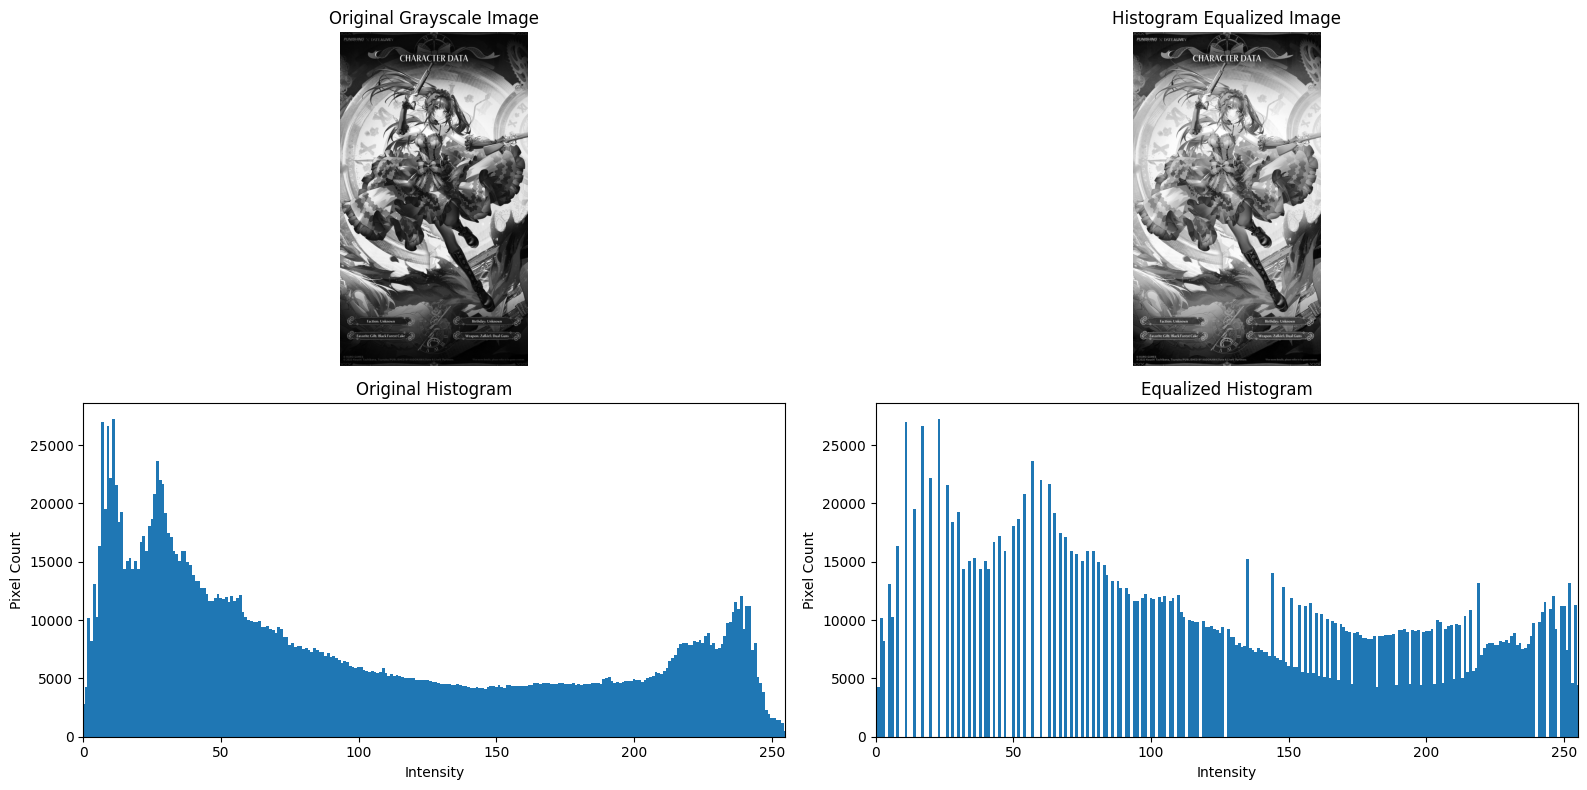

Saved: /content/labwork9_results/histogram_equalization.png


In [36]:
equalized_histogram = histogram_local_reduce(equalized_image, block_size=MAIN_BLOCK_SIZE)

plt.figure(figsize=(16, 8))

plt.subplot(2, 2, 1)
plt.imshow(gray_image, cmap="gray")
plt.title("Original Grayscale Image")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(equalized_image, cmap="gray")
plt.title("Histogram Equalized Image")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.bar(np.arange(256), histogram, width=1.0)
plt.title("Original Histogram")
plt.xlabel("Intensity")
plt.ylabel("Pixel Count")
plt.xlim(0, 255)

plt.subplot(2, 2, 4)
plt.bar(np.arange(256), equalized_histogram, width=1.0)
plt.title("Equalized Histogram")
plt.xlabel("Intensity")
plt.ylabel("Pixel Count")
plt.xlim(0, 255)

plt.tight_layout()

equalization_figure_path = os.path.join(OUTPUT_DIR, "histogram_equalization.png")

plt.savefig(equalization_figure_path, dpi=150, bbox_inches="tight")

plt.show()

print("Saved:", equalization_figure_path)

In [37]:
benchmark_results = []

block_size_histograms = {}

print("Testing different block sizes...")
print()

for block_size in BLOCK_SIZES:
    start = time.perf_counter()

    test_histogram = histogram_local_reduce(gray_image,block_size=block_size)

    histogram_elapsed = time.perf_counter() - start

    test_probability = calculate_probability(test_histogram, gray_image.size)

    start = time.perf_counter()

    test_cdf = calculate_cdf_sequential(test_probability)

    cdf_elapsed = time.perf_counter() - start

    test_mapping = calculate_equalization_mapping(test_cdf)

    start = time.perf_counter()

    test_equalized = equalize_image(gray_image, test_mapping, block_size=block_size)

    equalization_elapsed = time.perf_counter() - start

    histogram_correct = np.array_equal(test_histogram, reference_histogram)

    output_difference = np.abs(test_equalized.astype(np.int16) - equalized_image.astype(np.int16))

    max_difference = int(output_difference.max())
    mean_difference = float(output_difference.mean())

    benchmark_results.append({
        "Block Size": f"{block_size[0]}x{block_size[1]}",
        "Histogram (s)": histogram_elapsed,
        "CDF (s)": cdf_elapsed,
        "Equalization MAP (s)": equalization_elapsed,
        "Total (s)": (histogram_elapsed + cdf_elapsed + equalization_elapsed),
        "Histogram Correct": histogram_correct,
        "Max Output Difference": max_difference,
        "Mean Output Difference": mean_difference
    })

    block_size_histograms[f"{block_size[0]}x{block_size[1]}"] = test_histogram

    print(
        f"{block_size[0]}x{block_size[1]} | "
        f"Histogram: {histogram_elapsed:.6f}s | "
        f"CDF: {cdf_elapsed:.6f}s | "
        f"Equalization: {equalization_elapsed:.6f}s | "
        f"Total: {histogram_elapsed + cdf_elapsed + equalization_elapsed:.6f}s | "
        f"Correct: {histogram_correct}"
    )

benchmark_df = pd.DataFrame(benchmark_results)

print("\nBenchmark results:")
display(benchmark_df)

Testing different block sizes...

4x4 | Histogram: 1.338804s | CDF: 0.000065s | Equalization: 0.513500s | Total: 1.852369s | Correct: True
8x8 | Histogram: 1.829036s | CDF: 0.000115s | Equalization: 0.143950s | Total: 1.973101s | Correct: True
16x16 | Histogram: 1.050740s | CDF: 0.000065s | Equalization: 0.026243s | Total: 1.077048s | Correct: True
32x32 | Histogram: 0.855250s | CDF: 0.000115s | Equalization: 0.012614s | Total: 0.867979s | Correct: True
64x64 | Histogram: 0.831977s | CDF: 0.000115s | Equalization: 0.008659s | Total: 0.840751s | Correct: True

Benchmark results:


,Block Size,Histogram (s),CDF (s),Equalization MAP (s),Total (s),Histogram Correct,Max Output Difference,Mean Output Difference
0,4x4,1.338804,0.000065,0.513500,1.852369,True,0,0.0
1,8x8,1.829036,0.000115,0.143950,1.973101,True,0,0.0
2,16x16,1.050740,0.000065,0.026243,1.077048,True,0,0.0
3,32x32,0.855250,0.000115,0.012614,0.867979,True,0,0.0
4,64x64,0.831977,0.000115,0.008659,0.840751,True,0,0.0


In [38]:
probability_sum = probability.sum()

cdf_monotonic = np.all(np.diff(cdf) >= -1e-12)

cdf_in_range = (np.all(cdf >= 0.0) and np.all(cdf <= 1.0 + 1e-12))

mapping_monotonic = np.all(np.diff(mapping.astype(np.int16)) >= 0)

original_histogram_count = histogram.sum()
equalized_histogram_count = equalized_histogram.sum()

print("Correctness checks")
print("==================")

print(
    f"Histogram count correct: "
    f"{original_histogram_count == gray_image.size}"
)

print(
    f"Probability sum approximately 1: "
    f"{np.isclose(probability_sum, 1.0)}"
)

print(
    f"CDF is monotonic: "
    f"{cdf_monotonic}"
)

print(
    f"CDF is in [0,1]: "
    f"{cdf_in_range}"
)

print(
    f"Equalization mapping is monotonic: "
    f"{mapping_monotonic}"
)

print(
    f"Equalized image size unchanged: "
    f"{equalized_image.size == gray_image.size}"
)

print(
    f"Equalized histogram count correct: "
    f"{equalized_histogram_count == gray_image.size}"
)

Correctness checks
Histogram count correct: True
Probability sum approximately 1: True
CDF is monotonic: True
CDF is in [0,1]: True
Equalization mapping is monotonic: True
Equalized image size unchanged: True
Equalized histogram count correct: True


In [39]:
original_gray_path = os.path.join(OUTPUT_DIR, "original_grayscale.png")
equalized_path = os.path.join(OUTPUT_DIR, "equalized.png")

cv2.imwrite(original_gray_path, gray_image)
cv2.imwrite(equalized_path, equalized_image)

np.save(os.path.join(OUTPUT_DIR, "histogram.npy"), histogram)
np.save(os.path.join(OUTPUT_DIR, "probability.npy"), probability)
np.save(os.path.join(OUTPUT_DIR, "cdf.npy"), cdf)
np.save(os.path.join(OUTPUT_DIR, "equalization_mapping.npy"), mapping)
np.save(os.path.join(OUTPUT_DIR, "equalized_histogram.npy"), equalized_histogram)

benchmark_csv_path = os.path.join(OUTPUT_DIR, "benchmark.csv")

benchmark_df.to_csv(benchmark_csv_path, index=False)

print("Saved files:")
print("-", original_gray_path)
print("-", equalized_path)
print("-", histogram_figure_path)
print("-", equalization_figure_path)
print("-", benchmark_csv_path)
print("-", os.path.join(OUTPUT_DIR, "histogram.npy"))
print("-", os.path.join(OUTPUT_DIR, "probability.npy"))
print("-", os.path.join(OUTPUT_DIR, "cdf.npy"))
print("-", os.path.join(OUTPUT_DIR, "equalization_mapping.npy"))
print("-", os.path.join(OUTPUT_DIR, "equalized_histogram.npy"))

Saved files:
- /content/labwork9_results/original_grayscale.png
- /content/labwork9_results/equalized.png
- /content/labwork9_results/histogram.png
- /content/labwork9_results/histogram_equalization.png
- /content/labwork9_results/benchmark.csv
- /content/labwork9_results/histogram.npy
- /content/labwork9_results/probability.npy
- /content/labwork9_results/cdf.npy
- /content/labwork9_results/equalization_mapping.npy
- /content/labwork9_results/equalized_histogram.npy


In [40]:
print("=" * 65)
print("LABWORK 9 - HISTOGRAM EQUALIZATION")
print("=" * 65)

print(f"Image size              : {width} x {height}")
print(f"Total pixels            : {gray_image.size}")
print(f"Number of histogram bins: {len(histogram)}")

print("\n9a - Histogram")
print(f"Block size              : {MAIN_BLOCK_SIZE}")
print(f"Histogram correct       : {np.array_equal(histogram, reference_histogram)}")
print(f"Histogram count         : {histogram.sum()}")

print("\n9b - Histogram Equalization")
print(f"Probability sum         : {probability.sum():.12f}")
print(f"Final CDF value         : {cdf[-1]:.12f}")
print(f"Mapping range           : {mapping.min()} - {mapping.max()}")
print(f"Output image shape      : {equalized_image.shape}")

print("\nCorrectness")
print(f"CDF monotonic           : {cdf_monotonic}")
print(f"CDF in [0,1]            : {cdf_in_range}")
print(f"Mapping monotonic       : {mapping_monotonic}")

print("\nBlock-size experiments")
display(benchmark_df)

LABWORK 9 - HISTOGRAM EQUALIZATION
Image size              : 1080 x 1920
Total pixels            : 2073600
Number of histogram bins: 256

9a - Histogram
Block size              : (16, 16)
Histogram correct       : True
Histogram count         : 2073600

9b - Histogram Equalization
Probability sum         : 1.000000000000
Final CDF value         : 1.000000000000
Mapping range           : 0 - 255
Output image shape      : (1920, 1080)

Correctness
CDF monotonic           : True
CDF in [0,1]            : True
Mapping monotonic       : True

Block-size experiments


,Block Size,Histogram (s),CDF (s),Equalization MAP (s),Total (s),Histogram Correct,Max Output Difference,Mean Output Difference
0,4x4,1.338804,0.000065,0.513500,1.852369,True,0,0.0
1,8x8,1.829036,0.000115,0.143950,1.973101,True,0,0.0
2,16x16,1.050740,0.000065,0.026243,1.077048,True,0,0.0
3,32x32,0.855250,0.000115,0.012614,0.867979,True,0,0.0
4,64x64,0.831977,0.000115,0.008659,0.840751,True,0,0.0
